In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
import numpy as np
from pybaseball import statcast, playerid_reverse_lookup
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

GAME_DATE = '2026-06-03'
OPPONENT = 'ATL'
RESULT = 'L 3-7'
STARTER_NAME = 'Corbin, Patrick'
HOME_AWAY = 'AWAY'

SPOTLIGHT_PITCHER = None

SEASON_W = 29
SEASON_L = 32
SEASON_RS = 0
SEASON_RA = 0

PITCH_COLORS = {
    'FF': '#e74c3c', 'SL': '#3498db', 'CH': '#2ecc71',
    'CU': '#9b59b6', 'SI': '#1abc9c', 'FC': '#f59542',
    'ST': '#e84393', 'KC': '#e67e22', 'FS': '#f1c40f',
    'SV': '#8e44ad', 'KN': '#7f8c8d'
}

PITCH_NAMES = {
    'FF': '4-Seam', 'SL': 'Slider', 'CH': 'Changeup',
    'CU': 'Curveball', 'SI': 'Sinker', 'FC': 'Cutter',
    'ST': 'Sweeper', 'KC': 'K-Curve', 'FS': 'Splitter',
    'SV': 'Slurve', 'KN': 'Knuckle'
}

print("=== Blue Jays Game Report v2.1: " + GAME_DATE + " vs " + OPPONENT + " (" + RESULT + ") ===")
print("Season Record: " + str(SEASON_W) + "-" + str(SEASON_L))
if SPOTLIGHT_PITCHER:
    print("Spotlight Pitcher: " + SPOTLIGHT_PITCHER)
else:
    print("Spotlight Pitcher: None")

=== Blue Jays Game Report v2.1: 2026-06-03 vs ATL (L 3-7) ===
Season Record: 29-32
Spotlight Pitcher: None


In [23]:
game_data = statcast(start_dt=GAME_DATE, end_dt=GAME_DATE)

if 'TOR' in game_data['home_team'].values:
    jays_pitching = game_data[game_data['home_team'] == 'TOR']
    jays_pitchers = jays_pitching[jays_pitching['inning_topbot'] == 'Top']
    jays_batting = jays_pitching[jays_pitching['inning_topbot'] == 'Bot']
    print("Blue Jays: HOME")
else:
    jays_pitching = game_data[game_data['away_team'] == 'TOR']
    jays_pitchers = jays_pitching[jays_pitching['inning_topbot'] == 'Bot']
    jays_batting = jays_pitching[jays_pitching['inning_topbot'] == 'Top']
    print("Blue Jays: AWAY")

print("Total pitches in game: " + str(len(game_data)))
print("Blue Jays pitching data: " + str(len(jays_pitchers)) + " pitches")
print("Blue Jays batting data: " + str(len(jays_batting)) + " pitches")

starter = jays_pitchers[jays_pitchers['player_name'] == STARTER_NAME]
print("\n" + STARTER_NAME + ": " + str(len(starter)) + " pitches")

print("\n=== All Blue Jays pitchers in this game ===")
for name in jays_pitchers['player_name'].unique():
    count = len(jays_pitchers[jays_pitchers['player_name'] == name])
    print("  " + name + ": " + str(count) + " pitches")

This is a large query, it may take a moment to complete


100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  2.18it/s]

Blue Jays: AWAY
Total pitches in game: 4469
Blue Jays pitching data: 135 pitches
Blue Jays batting data: 139 pitches

Corbin, Patrick: 85 pitches

=== All Blue Jays pitchers in this game ===
  Juenger, Hayden: 11 pitches
  Macko, Adam: 17 pitches
  Rodríguez, Yariel: 22 pitches
  Corbin, Patrick: 85 pitches


In [24]:
print("\n" + "=" * 60)
print("  " + STARTER_NAME + " — Pitch Arsenal Performance (" + str(len(starter)) + " pitches)")
print("=" * 60)

print("{:<12} {:>4} {:>7} {:>7} {:>7} {:>7} {:>8} {:>7}".format(
    'Pitch', '#', 'Usage', 'Velo', 'Whiff%', 'CSW%', 'Chase%', 'Grade'))
print("-" * 70)

for pt in starter['pitch_type'].value_counts().index:
    pt_data = starter[starter['pitch_type'] == pt]
    count = len(pt_data)
    usage = count / len(starter) * 100
    avg_velo = pt_data['release_speed'].mean()

    swinging = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked'])
    swings = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                           'foul', 'foul_tip', 'hit_into_play',
                                           'hit_into_play_no_out', 'hit_into_play_score'])

    whiff_rate = (swinging.sum() / swings.sum() * 100) if swings.sum() > 0 else 0

    called = pt_data['description'].isin(['called_strike']).sum()
    csw = (swinging.sum() + called) / count * 100

    outside_zone = pt_data[(pt_data['plate_x'].abs() > 0.83) |
                           (pt_data['plate_z'] < 1.5) |
                           (pt_data['plate_z'] > 3.5)]
    chases = outside_zone['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                                'foul', 'foul_tip', 'hit_into_play',
                                                'hit_into_play_no_out', 'hit_into_play_score'])
    chase_rate = (chases.sum() / len(outside_zone) * 100) if len(outside_zone) > 0 else 0

    if whiff_rate >= 30: grade = '🟢 A'
    elif whiff_rate >= 20: grade = '🟢 B'
    elif whiff_rate >= 10: grade = '🟡 C'
    else: grade = '🔴 D'

    print("{:<12} {:>4} {:>6.1f}% {:>6.1f} {:>6.1f}% {:>6.1f}% {:>7.1f}% {:>7}".format(
        PITCH_NAMES.get(pt, pt), count, usage, avg_velo, whiff_rate, csw, chase_rate, grade))


  Corbin, Patrick — Pitch Arsenal Performance (85 pitches)
Pitch           #   Usage    Velo  Whiff%    CSW%   Chase%   Grade
----------------------------------------------------------------------
Slider         19   22.4%   78.2   16.7%   21.1%    21.4%     🟡 C
Sinker         18   21.2%   91.2    7.7%   22.2%    57.1%     🔴 D
Cutter         17   20.0%   86.1   18.2%   23.5%    33.3%     🟡 C
Changeup       16   18.8%   78.6    0.0%    0.0%    25.0%     🔴 D
4-Seam         13   15.3%   90.8    0.0%   15.4%    14.3%     🔴 D
Curveball       2    2.4%   67.9    0.0%  100.0%     0.0%     🔴 D



=== Corbin, Patrick — Pitch Movement (inches) ===
            h_break  v_break  count
pitch_type                         
CH              9.9      6.1     16
CU             -3.2     -1.0      2
FC             -2.9      5.5     17
FF              7.0     13.6     13
SI             13.1     10.8     18
SL             -3.3     -2.9     19
Chart saved!


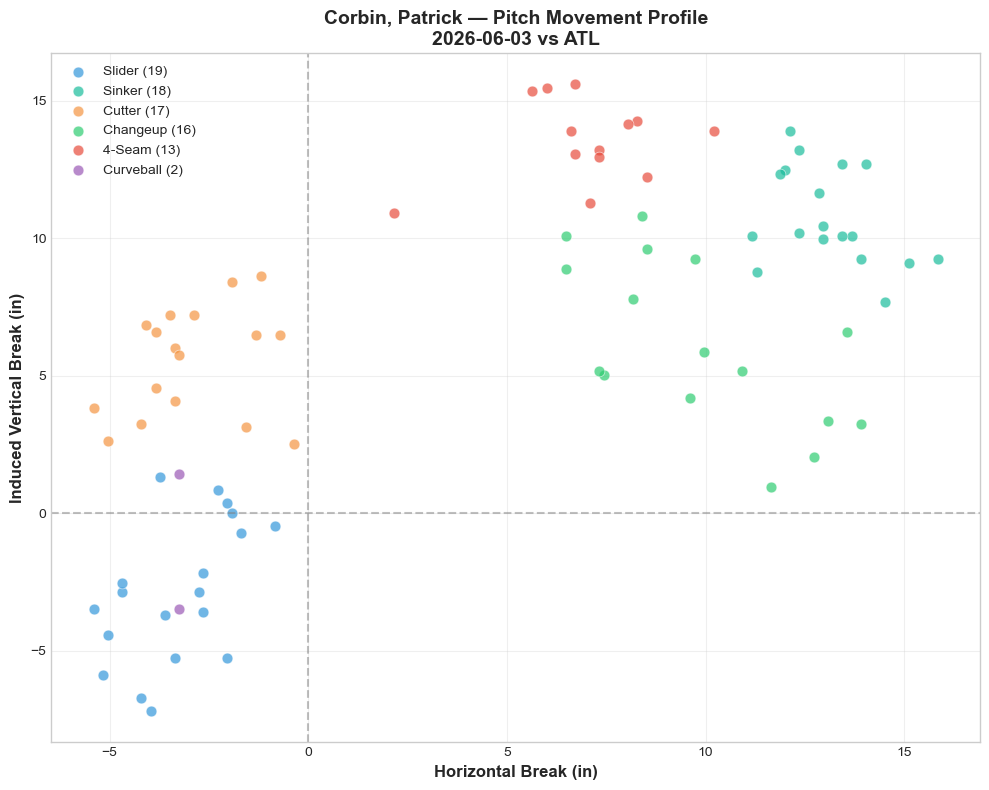

In [25]:
print("\n=== " + STARTER_NAME + " — Pitch Movement (inches) ===")
movement = starter.groupby('pitch_type').agg(
    h_break=('pfx_x', lambda x: x.mean() * 12),
    v_break=('pfx_z', lambda x: x.mean() * 12),
    count=('pitch_type', 'count')
).round(1)
movement = movement[movement['count'] >= 2]
print(movement)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for pt in starter['pitch_type'].value_counts().head(6).index:
    pt_data = starter[starter['pitch_type'] == pt]
    color = PITCH_COLORS.get(pt, '#95a5a6')
    ax.scatter(pt_data['pfx_x'] * 12, pt_data['pfx_z'] * 12,
              color=color, alpha=0.7, s=60,
              label=PITCH_NAMES.get(pt, pt) + ' (' + str(len(pt_data)) + ')',
              edgecolors='white', linewidth=0.5)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Horizontal Break (in)', fontsize=12, fontweight='bold')
ax.set_ylabel('Induced Vertical Break (in)', fontsize=12, fontweight='bold')
ax.set_title(STARTER_NAME + ' — Pitch Movement Profile\n' + GAME_DATE + ' vs ' + OPPONENT,
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../visualizations/movement_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

Chart saved!


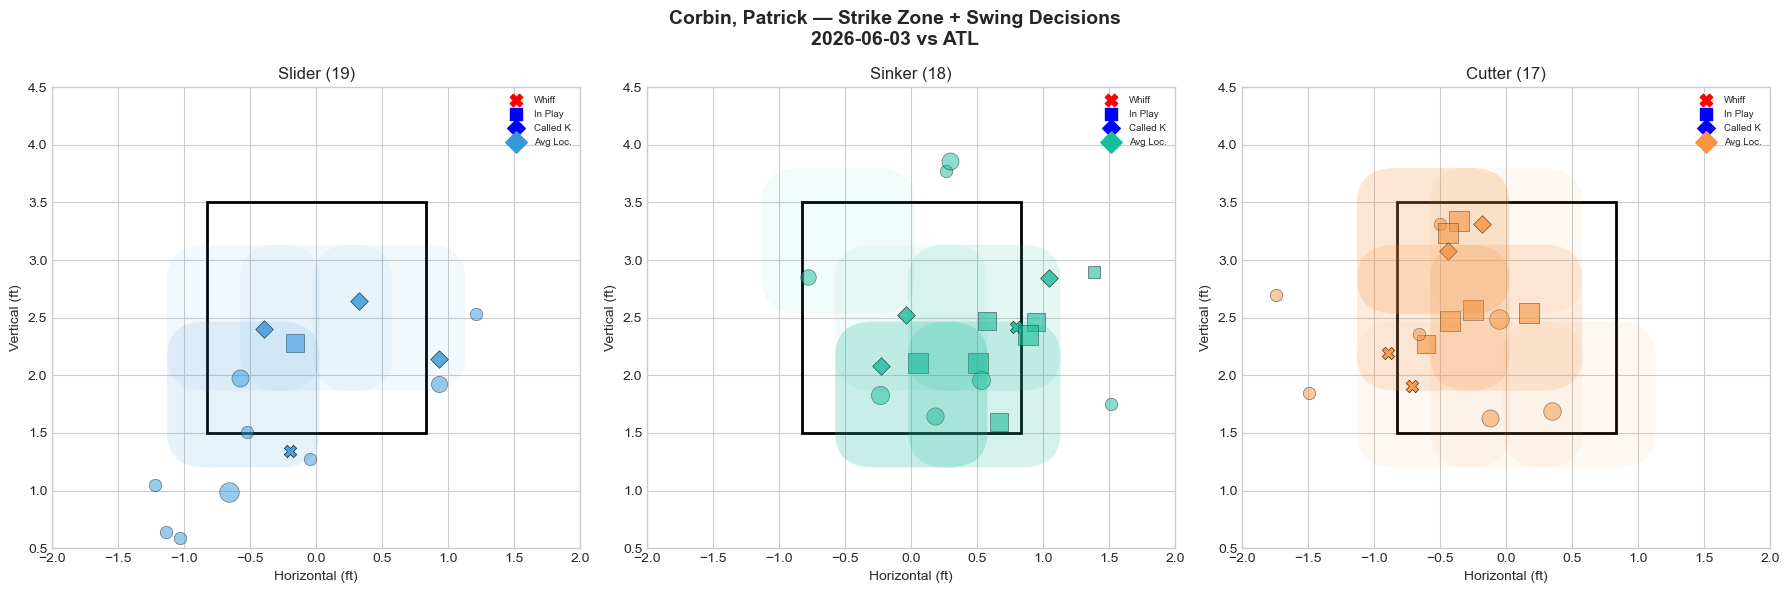

In [26]:
top_pitches = starter['pitch_type'].value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, len(top_pitches), figsize=(6*len(top_pitches), 6))
if len(top_pitches) == 1:
    axes = [axes]

for idx, pt in enumerate(top_pitches):
    ax = axes[idx]
    pt_data = starter[starter['pitch_type'] == pt]

    zone = plt.Rectangle((-0.83, 1.5), 1.66, 2.0, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(zone)

    for _, row in pt_data.iterrows():
        if pd.notna(row['plate_x']) and pd.notna(row['plate_z']):
            color = PITCH_COLORS.get(pt, '#95a5a6')
            if row['description'] in ['swinging_strike', 'swinging_strike_blocked']:
                marker = 'X'
                alpha = 0.9
            elif row['description'] in ['hit_into_play', 'hit_into_play_no_out', 'hit_into_play_score']:
                marker = 's'
                alpha = 0.6
            elif row['description'] == 'called_strike':
                marker = 'D'
                alpha = 0.8
            else:
                marker = 'o'
                alpha = 0.5

            ev = row.get('launch_speed', 0)
            if pd.isna(ev):
                ev = 0
            size = max(80, min(200, ev * 2))

            ax.scatter(row['plate_x'], row['plate_z'], color=color, marker=marker,
                      s=size, alpha=alpha, edgecolors='black', linewidth=0.5)

    from matplotlib.patches import FancyBboxPatch
    import matplotlib.colors as mcolors

    x_bins = np.linspace(-0.83, 0.83, 4)
    z_bins = np.linspace(1.5, 3.5, 4)

    for i in range(len(x_bins)-1):
        for j in range(len(z_bins)-1):
            zone_mask = (pt_data['plate_x'] >= x_bins[i]) & (pt_data['plate_x'] < x_bins[i+1]) & \
                       (pt_data['plate_z'] >= z_bins[j]) & (pt_data['plate_z'] < z_bins[j+1])
            zone_count = zone_mask.sum()
            if zone_count > 0:
                intensity = min(zone_count / 5, 1.0)
                hex_zone = FancyBboxPatch((x_bins[i], z_bins[j]),
                                          x_bins[i+1]-x_bins[i], z_bins[j+1]-z_bins[j],
                                          alpha=intensity * 0.3,
                                          facecolor=PITCH_COLORS.get(pt, '#95a5a6'),
                                          edgecolor='none')
                ax.add_patch(hex_zone)

    whiff_marker = ax.scatter([], [], color='red', marker='X', s=80, label='Whiff')
    inplay_marker = ax.scatter([], [], color='blue', marker='s', s=80, label='In Play')
    called_marker = ax.scatter([], [], color='blue', marker='D', s=80, label='Called K')
    avg_marker = ax.scatter([], [], color=PITCH_COLORS.get(pt, '#95a5a6'), marker='D', s=120, label='Avg Loc.')

    ax.legend(fontsize=7, loc='upper right')
    ax.set_xlim(-2, 2)
    ax.set_ylim(0.5, 4.5)
    ax.set_xlabel('Horizontal (ft)')
    ax.set_ylabel('Vertical (ft)')
    ax.set_title(PITCH_NAMES.get(pt, pt) + ' (' + str(len(pt_data)) + ')')

fig.suptitle(STARTER_NAME + ' — Strike Zone + Swing Decisions\n' + GAME_DATE + ' vs ' + OPPONENT,
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/zone_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

In [27]:
print("\n=== " + STARTER_NAME + " vs LHB/RHB ===")
splits = starter.groupby('stand').agg(
    pitches=('pitch_type', 'count'),
    avg_velo=('release_speed', 'mean'),
    swinging_strikes=('description', lambda x: x.isin(['swinging_strike', 'swinging_strike_blocked']).sum()),
    whiff_per_pitch=('description', lambda x: x.isin(['swinging_strike', 'swinging_strike_blocked']).sum() / len(x) * 100 if len(x) > 0 else 0)
).round(1)
print(splits)


=== Corbin, Patrick vs LHB/RHB ===
       pitches  avg_velo  swinging_strikes  whiff_per_pitch
stand                                                      
L           18      87.2                 1              5.6
R           67      83.5                 3              4.5


In [28]:
print("\n=== " + STARTER_NAME + " — Pitch Selection by Count ===")

count_groups = {
    'First pitch (0-0)': starter[(starter['balls'] == 0) & (starter['strikes'] == 0)],
    'Ahead (0-1, 0-2, 1-2)': starter[((starter['balls'] == 0) & (starter['strikes'].isin([1,2]))) |
                                       ((starter['balls'] == 1) & (starter['strikes'] == 2))],
    'Behind (1-0, 2-0, 3-0, 2-1, 3-1)': starter[((starter['balls'].isin([1,2,3])) & (starter['strikes'] == 0)) |
                                                   ((starter['balls'].isin([2,3])) & (starter['strikes'] == 1))],
    'Even (1-1, 2-2)': starter[((starter['balls'] == 1) & (starter['strikes'] == 1)) |
                                ((starter['balls'] == 2) & (starter['strikes'] == 2))],
    'Full count (3-2)': starter[(starter['balls'] == 3) & (starter['strikes'] == 2)]
}

for situation, data in count_groups.items():
    if len(data) > 0:
        print("\n--- " + situation + " (" + str(len(data)) + " pitches) ---")
        for pt in data['pitch_type'].value_counts().index:
            pct = len(data[data['pitch_type'] == pt]) / len(data) * 100
            print("  " + PITCH_NAMES.get(pt, pt) + ": " + str(round(pct, 1)) + "%")

print("\n=== Strikeout Pitch (" + str(starter[starter['events'] == 'strikeout']['pitch_type'].count()) + " K's) ===")
k_pitches = starter[starter['events'] == 'strikeout']['pitch_type'].value_counts()
print(k_pitches)


=== Corbin, Patrick — Pitch Selection by Count ===

--- First pitch (0-0) (23 pitches) ---
  Slider: 26.1%
  Sinker: 26.1%
  Cutter: 21.7%
  4-Seam: 17.4%
  Curveball: 8.7%

--- Ahead (0-1, 0-2, 1-2) (22 pitches) ---
  Changeup: 31.8%
  Cutter: 22.7%
  4-Seam: 22.7%
  Slider: 22.7%

--- Behind (1-0, 2-0, 3-0, 2-1, 3-1) (14 pitches) ---
  Sinker: 35.7%
  Cutter: 28.6%
  Slider: 21.4%
  Changeup: 7.1%
  4-Seam: 7.1%

--- Even (1-1, 2-2) (19 pitches) ---
  Changeup: 36.8%
  Sinker: 21.1%
  4-Seam: 15.8%
  Slider: 15.8%
  Cutter: 10.5%

--- Full count (3-2) (7 pitches) ---
  Sinker: 42.9%
  Slider: 28.6%
  Changeup: 14.3%
  Cutter: 14.3%

=== Strikeout Pitch (1 K's) ===
pitch_type
CH    1
Name: count, dtype: int64


In [29]:
from pybaseball import playerid_reverse_lookup

print("\n=== Top Opposing Batters vs " + STARTER_NAME + " ===")

batter_stats = starter.groupby('batter').agg(
    pitches=('pitch_type', 'count'),
    hits=('events', lambda x: x.isin(['single', 'double', 'triple', 'home_run']).sum()),
    strikeouts=('events', lambda x: (x == 'strikeout').sum()),
    walks=('events', lambda x: (x == 'walk').sum()),
    avg_exit_velo=('launch_speed', 'mean')
).round(1)

batter_stats = batter_stats.sort_values('pitches', ascending=False).head(5)

try:
    batter_ids = batter_stats.index.tolist()
    batter_names = playerid_reverse_lookup(batter_ids, key_type='mlbam')
    batter_names['full_name'] = batter_names['name_last'] + ', ' + batter_names['name_first']
    name_map = dict(zip(batter_names['key_mlbam'], batter_names['full_name']))
    batter_stats.index = [name_map.get(bid, str(bid)) for bid in batter_stats.index]
except:
    pass

batter_stats.index.name = 'batter_name'
print(batter_stats)

print("\n=== Detailed Pitch Breakdown ===")
for batter_name in batter_stats.index[:3]:
    if isinstance(batter_name, str):
        batter_key = batter_name
    else:
        batter_key = str(batter_name)

    try:
        if batter_key in name_map.values():
            batter_id = [k for k, v in name_map.items() if v == batter_key][0]
        else:
            batter_id = int(batter_key)
        batter_pitches = starter[starter['batter'] == batter_id]
    except:
        continue

    print("\n--- " + batter_key + " (" + str(len(batter_pitches)) + " pitches) ---")
    pitch_mix = batter_pitches['pitch_type'].value_counts().to_dict()
    print("  Pitches faced: " + str(pitch_mix))
    whiffs = batter_pitches['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
    fouls = (batter_pitches['description'] == 'foul').sum()
    called = (batter_pitches['description'] == 'called_strike').sum()
    balls = batter_pitches['description'].isin(['ball', 'blocked_ball', 'hit_by_pitch']).sum()
    inplay = batter_pitches['description'].isin(['hit_into_play', 'hit_into_play_no_out', 'hit_into_play_score']).sum()
    print("  Results: " + str(whiffs) + " whiffs, " + str(fouls) + " fouls, " + str(called) + " called strikes, " + str(balls) + " balls, " + str(inplay) + " in play")
    outcomes = batter_pitches['events'].dropna().tolist()
    print("  Outcomes: " + str(outcomes))


=== Top Opposing Batters vs Corbin, Patrick ===
               pitches  hits  strikeouts  walks  avg_exit_velo
batter_name                                                   
acuña, ronald       17     1           1      0           79.9
kim, ha-seong       12     1           0      0           83.1
olson, matt         11     2           0      0           92.6
riley, austin       11     0           0      1           98.4
white, eli          10     0           0      1           71.1

=== Detailed Pitch Breakdown ===

--- acuña, ronald (17 pitches) ---
  Pitches faced: {'CH': 5, 'SL': 4, 'SI': 3, 'FF': 3, 'FC': 2}
  Results: 1 whiffs, 6 fouls, 1 called strikes, 6 balls, 2 in play
  Outcomes: ['double', 'field_out', 'strikeout']

--- kim, ha-seong (12 pitches) ---
  Pitches faced: {'SL': 4, 'SI': 3, 'CH': 3, 'FF': 2}
  Results: 1 whiffs, 4 fouls, 1 called strikes, 4 balls, 2 in play
  Outcomes: ['field_out', 'single']

--- olson, matt (11 pitches) ---
  Pitches faced: {'FC': 5, 'FF': 3

Chart saved!


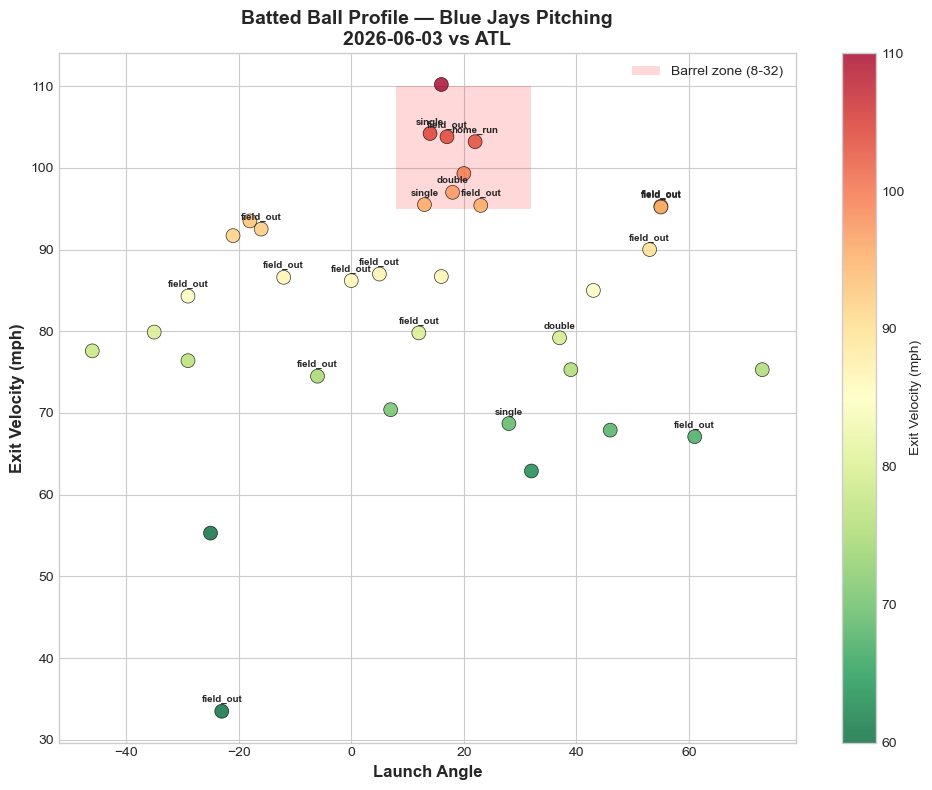


=== Batted Ball Summary ===
Total balls in play: 35
Avg exit velocity: 83.6 mph
Avg launch angle: 12.7
Hard hit (95+ mph): 10/35 (29%)


In [30]:
batted = starter.dropna(subset=['launch_speed', 'launch_angle'])

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

barrel_zone = plt.Rectangle((8, 95), 24, 15, alpha=0.15, facecolor='red', label='Barrel zone (8-32)')
ax.add_patch(barrel_zone)

if len(batted) > 0:
    scatter = ax.scatter(batted['launch_angle'], batted['launch_speed'],
                        c=batted['launch_speed'], cmap='RdYlGn_r',
                        s=100, alpha=0.8, edgecolors='black', linewidth=0.5,
                        vmin=60, vmax=110)
    plt.colorbar(scatter, ax=ax, label='Exit Velocity (mph)')

    for _, row in batted.iterrows():
        event = row.get('events', '')
        if pd.notna(event) and event != '':
            ax.annotate(event, (row['launch_angle'], row['launch_speed']),
                       fontsize=7, fontweight='bold', ha='center', va='bottom',
                       xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('Launch Angle', fontsize=12, fontweight='bold')
ax.set_ylabel('Exit Velocity (mph)', fontsize=12, fontweight='bold')
ax.set_title('Batted Ball Profile — Blue Jays Pitching\n' + GAME_DATE + ' vs ' + OPPONENT,
            fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/batted_balls_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

print("\n=== Batted Ball Summary ===")
total_bip = len(batted)
print("Total balls in play: " + str(total_bip))
if total_bip > 0:
    print("Avg exit velocity: " + str(round(batted['launch_speed'].mean(), 1)) + " mph")
    print("Avg launch angle: " + str(round(batted['launch_angle'].mean(), 1)))
    hard_hit = (batted['launch_speed'] >= 95).sum()
    print("Hard hit (95+ mph): " + str(hard_hit) + "/" + str(total_bip) + " (" + str(round(hard_hit/total_bip*100)) + "%)")

Chart saved!


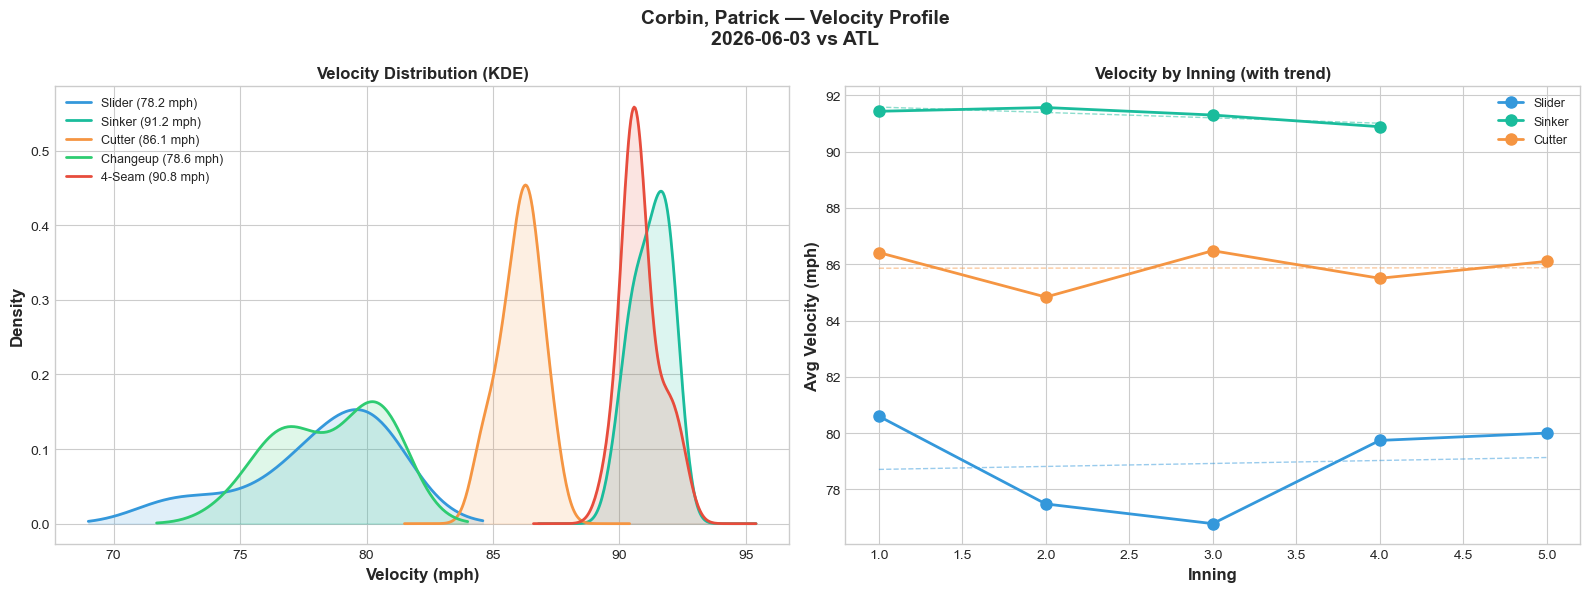

Slider: 80.6 -> 80.0 mph (-0.6 mph)
Sinker: 91.4 -> 90.9 mph (-0.5 mph)
Cutter: 86.4 -> 86.1 mph (-0.3 mph)


In [31]:
top_3 = starter['pitch_type'].value_counts().head(3).index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for pt in starter['pitch_type'].value_counts().head(5).index:
    pt_data = starter[starter['pitch_type'] == pt]['release_speed'].dropna()
    if len(pt_data) >= 2:
        try:
            kde = gaussian_kde(pt_data)
            x_range = np.linspace(pt_data.min() - 3, pt_data.max() + 3, 200)
            ax1.plot(x_range, kde(x_range), color=PITCH_COLORS.get(pt, '#95a5a6'),
                    label=PITCH_NAMES.get(pt, pt) + ' (' + str(round(pt_data.mean(), 1)) + ' mph)',
                    linewidth=2)
            ax1.fill_between(x_range, kde(x_range), alpha=0.15, color=PITCH_COLORS.get(pt, '#95a5a6'))
        except:
            pass

ax1.set_xlabel('Velocity (mph)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Velocity Distribution (KDE)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

for pt in top_3:
    pt_data = starter[starter['pitch_type'] == pt]
    inning_velo = pt_data.groupby('inning')['release_speed'].mean()
    ax2.plot(inning_velo.index, inning_velo.values, 'o-',
            color=PITCH_COLORS.get(pt, '#95a5a6'),
            label=PITCH_NAMES.get(pt, pt), linewidth=2, markersize=8)
    z = np.polyfit(inning_velo.index, inning_velo.values, 1)
    p = np.poly1d(z)
    ax2.plot(inning_velo.index, p(inning_velo.index), '--',
            color=PITCH_COLORS.get(pt, '#95a5a6'), alpha=0.5, linewidth=1)

ax2.set_xlabel('Inning', fontsize=12, fontweight='bold')
ax2.set_ylabel('Avg Velocity (mph)', fontsize=12, fontweight='bold')
ax2.set_title('Velocity by Inning (with trend)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

fig.suptitle(STARTER_NAME + ' — Velocity Profile\n' + GAME_DATE + ' vs ' + OPPONENT,
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/velocity_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

for pt in top_3:
    pt_data = starter[starter['pitch_type'] == pt]
    inning_velo = pt_data.groupby('inning')['release_speed'].mean()
    if len(inning_velo) >= 2:
        first = inning_velo.iloc[0]
        last = inning_velo.iloc[-1]
        diff = last - first
        print(PITCH_NAMES.get(pt, pt) + ": " + str(round(first, 1)) + " -> " + str(round(last, 1)) + " mph (" + ("+" if diff >= 0 else "") + str(round(diff, 1)) + " mph)")

Chart saved!


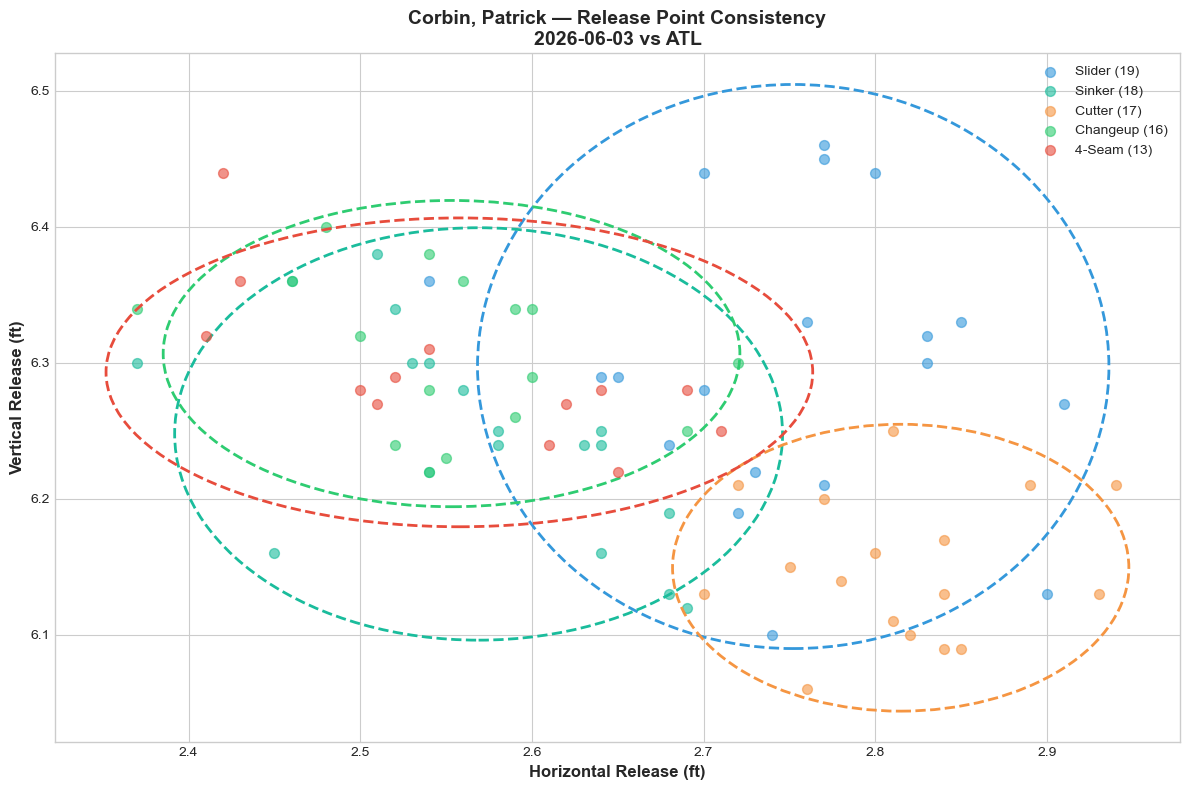


=== Release Point Spread (std dev in inches) ===
  Slider: H=1.1in, V=1.2in, Total=1.7in 🟢 Tight
  Sinker: H=1.1in, V=0.9in, Total=1.4in 🟢 Tight
  Cutter: H=0.8in, V=0.6in, Total=1.0in 🟢 Tight
  Changeup: H=1.0in, V=0.7in, Total=1.2in 🟢 Tight
  4-Seam: H=1.2in, V=0.7in, Total=1.4in 🟢 Tight


In [32]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

for pt in starter['pitch_type'].value_counts().head(5).index:
    pt_data = starter[starter['pitch_type'] == pt]
    ax.scatter(pt_data['release_pos_x'], pt_data['release_pos_z'],
              color=PITCH_COLORS.get(pt, '#95a5a6'), alpha=0.6, s=50,
              label=PITCH_NAMES.get(pt, pt) + ' (' + str(len(pt_data)) + ')')

    if len(pt_data) >= 3:
        from matplotlib.patches import Ellipse
        mean_x = pt_data['release_pos_x'].mean()
        mean_z = pt_data['release_pos_z'].mean()
        std_x = pt_data['release_pos_x'].std()
        std_z = pt_data['release_pos_z'].std()
        ellipse = Ellipse((mean_x, mean_z), std_x * 4, std_z * 4,
                         fill=False, edgecolor=PITCH_COLORS.get(pt, '#95a5a6'),
                         linewidth=2, linestyle='--')
        ax.add_patch(ellipse)

ax.set_xlabel('Horizontal Release (ft)', fontsize=12, fontweight='bold')
ax.set_ylabel('Vertical Release (ft)', fontsize=12, fontweight='bold')
ax.set_title(STARTER_NAME + ' — Release Point Consistency\n' + GAME_DATE + ' vs ' + OPPONENT,
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../visualizations/release_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()

print("\n=== Release Point Spread (std dev in inches) ===")
for pt in starter['pitch_type'].value_counts().head(5).index:
    pt_data = starter[starter['pitch_type'] == pt]
    if len(pt_data) >= 3:
        h_spread = pt_data['release_pos_x'].std() * 12
        v_spread = pt_data['release_pos_z'].std() * 12
        total = np.sqrt(h_spread**2 + v_spread**2)
        rating = "🟢 Tight" if total < 3.0 else "🟡 Moderate" if total < 5.0 else "🔴 Wide"
        print("  " + PITCH_NAMES.get(pt, pt) + ": H=" + str(round(h_spread, 1)) + "in, V=" + str(round(v_spread, 1)) + "in, Total=" + str(round(total, 1)) + "in " + rating)

In [33]:
print("\n=== " + STARTER_NAME + " — Pitch Tunneling Analysis ===")

pitch_types = starter['pitch_type'].value_counts()
pitch_types = pitch_types[pitch_types >= 3].index.tolist()

tunnel_results = []

for i in range(len(pitch_types)):
    for j in range(i+1, len(pitch_types)):
        pt1 = pitch_types[i]
        pt2 = pitch_types[j]

        data1 = starter[starter['pitch_type'] == pt1]
        data2 = starter[starter['pitch_type'] == pt2]

        rel_x1 = data1['release_pos_x'].mean()
        rel_z1 = data1['release_pos_z'].mean()
        rel_x2 = data2['release_pos_x'].mean()
        rel_z2 = data2['release_pos_z'].mean()
        release_sim = np.sqrt((rel_x1 - rel_x2)**2 + (rel_z1 - rel_z2)**2) * 12

        plate_x1 = data1['pfx_x'].mean() * 12
        plate_z1 = data1['pfx_z'].mean() * 12
        plate_x2 = data2['pfx_x'].mean() * 12
        plate_z2 = data2['pfx_z'].mean() * 12
        plate_sep = np.sqrt((plate_x1 - plate_x2)**2 + (plate_z1 - plate_z2)**2)

        velo1 = data1['release_speed'].mean()
        velo2 = data2['release_speed'].mean()
        velo_gap = abs(velo1 - velo2)

        tunnel_score = plate_sep / max(release_sim, 0.1)

        tunnel_results.append({
            'pair': PITCH_NAMES.get(pt1, pt1) + '/' + PITCH_NAMES.get(pt2, pt2),
            'release_sim': release_sim,
            'plate_sep': plate_sep,
            'tunnel': tunnel_score,
            'velo_gap': velo_gap
        })

tunnel_results.sort(key=lambda x: x['tunnel'], reverse=True)

print("\n{:<25} {:>12} {:>12} {:>8} {:>10}".format('Pair', 'Release Sim', 'Plate Sep', 'Tunnel', 'Velo Gap'))
print("-" * 70)
for t in tunnel_results:
    rating = "🟢" if t['tunnel'] >= 3.0 else "🟡" if t['tunnel'] >= 2.0 else "🔴"
    print("{:<25} {:>10.1f}in {:>10.1f}in {} {:>5.1f} {:>8.1f}mph".format(
        t['pair'], t['release_sim'], t['plate_sep'], rating, t['tunnel'], t['velo_gap']))

best = tunnel_results[0]
print("\n🏆 Best Tunnel: " + best['pair'] + " (score: " + str(round(best['tunnel'], 1)) + ")")


=== Corbin, Patrick — Pitch Tunneling Analysis ===

Pair                       Release Sim    Plate Sep   Tunnel   Velo Gap
----------------------------------------------------------------------
Changeup/4-Seam                  0.2in        8.0in 🟢  45.8     12.3mph
Sinker/4-Seam                    0.6in        6.7in 🟢  12.0      0.4mph
Slider/Sinker                    2.3in       21.3in 🟢   9.4     13.1mph
Slider/4-Seam                    2.3in       19.4in 🟢   8.3     12.7mph
Sinker/Changeup                  0.7in        5.7in 🟢   7.7     12.7mph
Slider/Changeup                  2.4in       16.0in 🟢   6.7      0.4mph
Sinker/Cutter                    3.2in       16.9in 🟢   5.3      5.2mph
Slider/Cutter                    1.9in        8.4in 🟢   4.4      7.9mph
Cutter/4-Seam                    3.5in       12.8in 🟢   3.6      4.8mph
Cutter/Changeup                  3.7in       12.8in 🟢   3.5      7.5mph

🏆 Best Tunnel: Changeup/4-Seam (score: 45.8)



=== Corbin, Patrick — Game Score Analysis ===
Game Score: 51
  Base: 50
  + Outs recorded: +21
  + Bonus K's (after 4th): +0
  - Hits: -12
  - Home runs: -4
  - Walks/HBP: -4
Rating: 🟡 QUALITY
Chart saved!


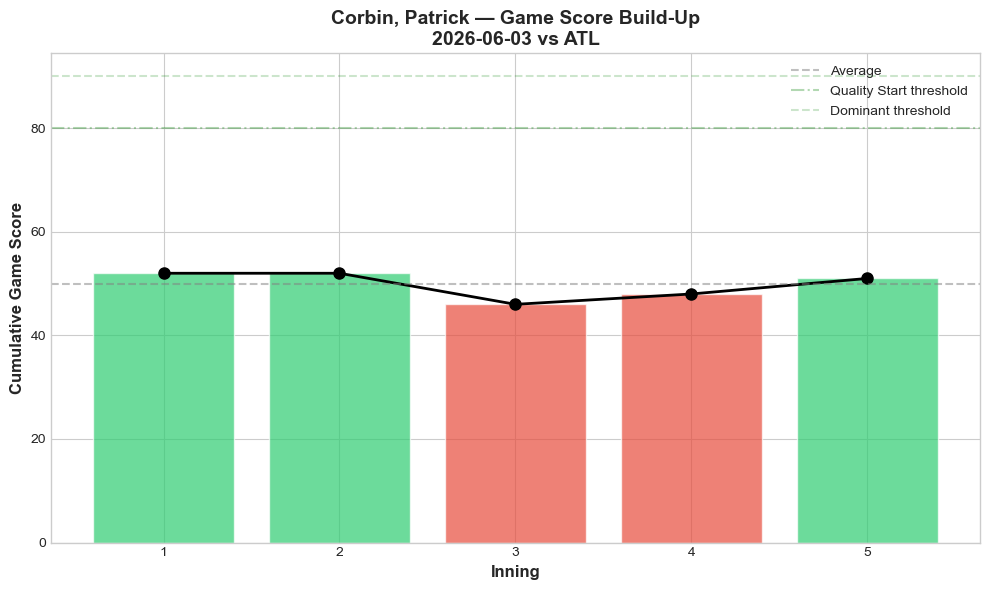

In [34]:
print("\n=== " + STARTER_NAME + " — Game Score Analysis ===")

innings_pitched = starter['inning'].nunique()
outs = len(starter[starter['events'].notna() & ~starter['events'].isin(['walk', 'hit_by_pitch', 'sac_fly', 'sac_bunt', 'catcher_interf'])])

ks = (starter['events'] == 'strikeout').sum()
hits = starter['events'].isin(['single', 'double', 'triple', 'home_run']).sum()
hrs = (starter['events'] == 'home_run').sum()
walks_hbp = starter['events'].isin(['walk', 'hit_by_pitch']).sum()

gs = 50 + outs - hits * 2 - hrs * 4 - walks_hbp * 2 + max(0, ks - 4) * 2

print("Game Score: " + str(gs))
print("  Base: 50")
print("  + Outs recorded: +" + str(outs))
print("  + Bonus K's (after 4th): +" + str(max(0, ks - 4) * 2))
print("  - Hits: -" + str(hits * 2))
print("  - Home runs: -" + str(hrs * 4))
print("  - Walks/HBP: -" + str(walks_hbp * 2))

if gs >= 80: rating = "🟢 DOMINANT"
elif gs >= 60: rating = "🟢 QUALITY"
elif gs >= 50: rating = "🟡 QUALITY"
elif gs >= 40: rating = "🟡 AVERAGE"
else: rating = "🔴 POOR"
print("Rating: " + rating)

fig, ax = plt.subplots(figsize=(10, 6))

innings = sorted(starter['inning'].unique())
cumulative_gs = []
running_gs = 50

for inn in innings:
    inn_data = starter[starter['inning'] == inn]
    inn_outs = len(inn_data[inn_data['events'].notna() & ~inn_data['events'].isin(['walk', 'hit_by_pitch'])])
    inn_ks = (inn_data['events'] == 'strikeout').sum()
    inn_hits = inn_data['events'].isin(['single', 'double', 'triple', 'home_run']).sum()
    inn_hrs = (inn_data['events'] == 'home_run').sum()
    inn_walks = inn_data['events'].isin(['walk', 'hit_by_pitch']).sum()

    running_gs += inn_outs - inn_hits * 2 - inn_hrs * 4 - inn_walks * 2
    if sum(1 for cgs in cumulative_gs if True) >= 3:
        running_gs += inn_ks * 2
    cumulative_gs.append(running_gs)

bar_colors = ['#2ecc71' if cgs >= 50 else '#e74c3c' for cgs in cumulative_gs]
ax.bar(innings, cumulative_gs, color=bar_colors, alpha=0.7, edgecolor='white')
ax.plot(innings, cumulative_gs, 'ko-', linewidth=2, markersize=8)

ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Average')
ax.axhline(y=80, color='green', linestyle='-.', alpha=0.3, label='Quality Start threshold')
ax.axhline(y=90, color='green', linestyle='--', alpha=0.2, label='Dominant threshold')

ax.set_xlabel('Inning', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Game Score', fontsize=12, fontweight='bold')
ax.set_title(STARTER_NAME + ' — Game Score Build-Up\n' + GAME_DATE + ' vs ' + OPPONENT,
            fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/gamescore_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
print("Chart saved!")
plt.show()


=== Key WPA Moments ===
Chart saved!


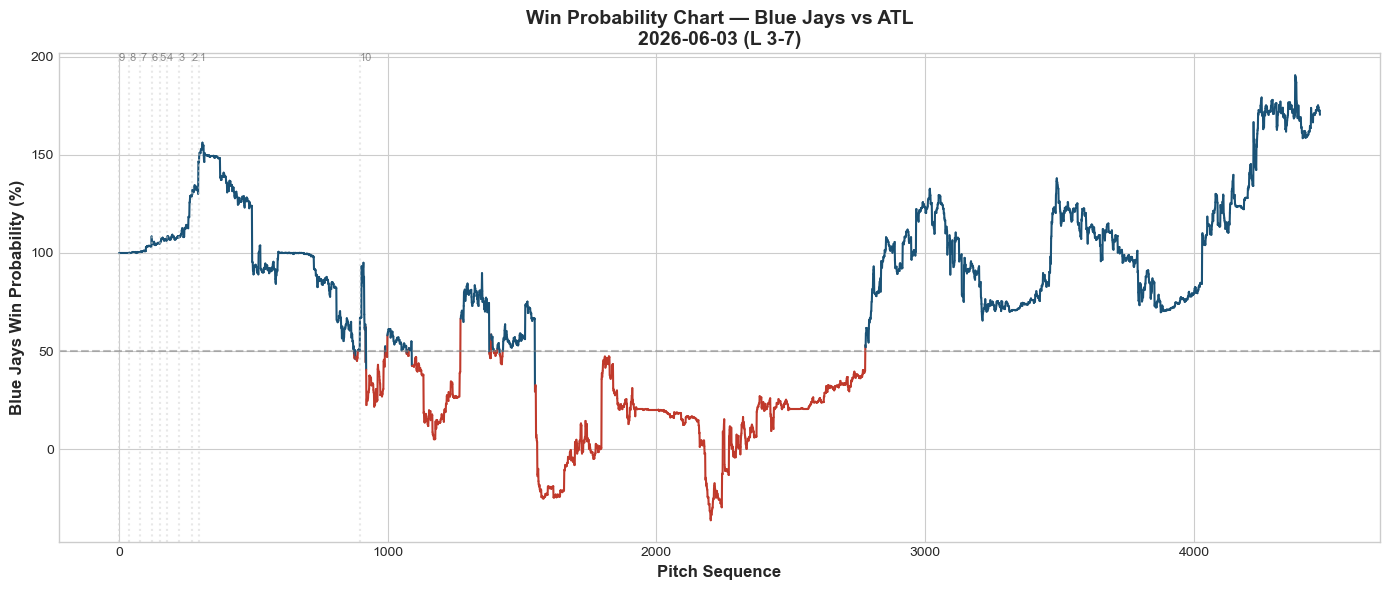

  📈 Inning 8: Soto, Gregory — triple (WP 29.4%)
  📈 Inning 3: Corbin, Patrick — home_run (WP 95.7%)
  📈 Inning 8: Soto, Gregory — walk (WP 6.2%)
  📉 Inning 4: Arrighetti, Spencer — home_run (WP 35.7%)
  📉 Inning 8: Beeter, Clayton — single (WP 166.6%)
  📉 Inning 9: Santillan, Tony — single (WP 66.5%)


In [35]:
print("\n=== Key WPA Moments ===")

if 'delta_home_win_exp' in game_data.columns:
    wpa_data = game_data.dropna(subset=['delta_home_win_exp']).copy()
    wpa_data['delta_home_win_exp'] = wpa_data['delta_home_win_exp'].astype(float)

    if HOME_AWAY == 'AWAY':
        wpa_data['tor_wp'] = 1 - wpa_data['delta_home_win_exp'].cumsum()
    else:
        wpa_data['tor_wp'] = wpa_data['delta_home_win_exp'].cumsum()

    wpa_data['tor_wp'] = wpa_data['tor_wp'] * 100

    fig, ax = plt.subplots(figsize=(14, 6))

    for i in range(len(wpa_data) - 1):
        color = '#1a5276' if wpa_data.iloc[i]['tor_wp'] >= 50 else '#c0392b'
        ax.plot([i, i+1], [wpa_data.iloc[i]['tor_wp'], wpa_data.iloc[i+1]['tor_wp']],
               color=color, linewidth=1.5)

    if wpa_data.iloc[-1]['tor_wp'] < 50:
        ax.fill_between(range(len(wpa_data)), wpa_data['tor_wp'].values, 50,
                        where=wpa_data['tor_wp'].values < 50,
                        alpha=0.1, color='red')

    ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel('Blue Jays Win Probability (%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pitch Sequence', fontsize=12, fontweight='bold')
    ax.set_title('Win Probability Chart — Blue Jays vs ' + OPPONENT + '\n' + GAME_DATE + ' (' + RESULT + ')',
                fontsize=14, fontweight='bold')

    for inn in game_data['inning'].unique():
        inn_start = game_data[game_data['inning'] == inn].index[0]
        idx = list(game_data.index).index(inn_start)
        ax.axvline(x=idx, color='lightgray', linestyle=':', alpha=0.5)
        ax.text(idx, ax.get_ylim()[1] * 0.98, str(inn), fontsize=8, alpha=0.5)

    plt.tight_layout()
    plt.savefig('../visualizations/wpa_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    top_moments = wpa_data.nlargest(3, 'delta_home_win_exp')
    bot_moments = wpa_data.nsmallest(3, 'delta_home_win_exp')
    key_moments = pd.concat([top_moments, bot_moments])

    for _, row in key_moments.iterrows():
        direction = "📈" if row['delta_home_win_exp'] > 0 else "📉"
        player = row.get('player_name', 'Unknown')
        event = row.get('events', '')
        inning = int(row['inning'])
        print("  " + direction + " Inning " + str(inning) + ": " + str(player) + " — " + str(event) + " (WP " + str(round(row['tor_wp'], 1)) + "%)")
else:
    print("WPA data not available.")

Chart saved!


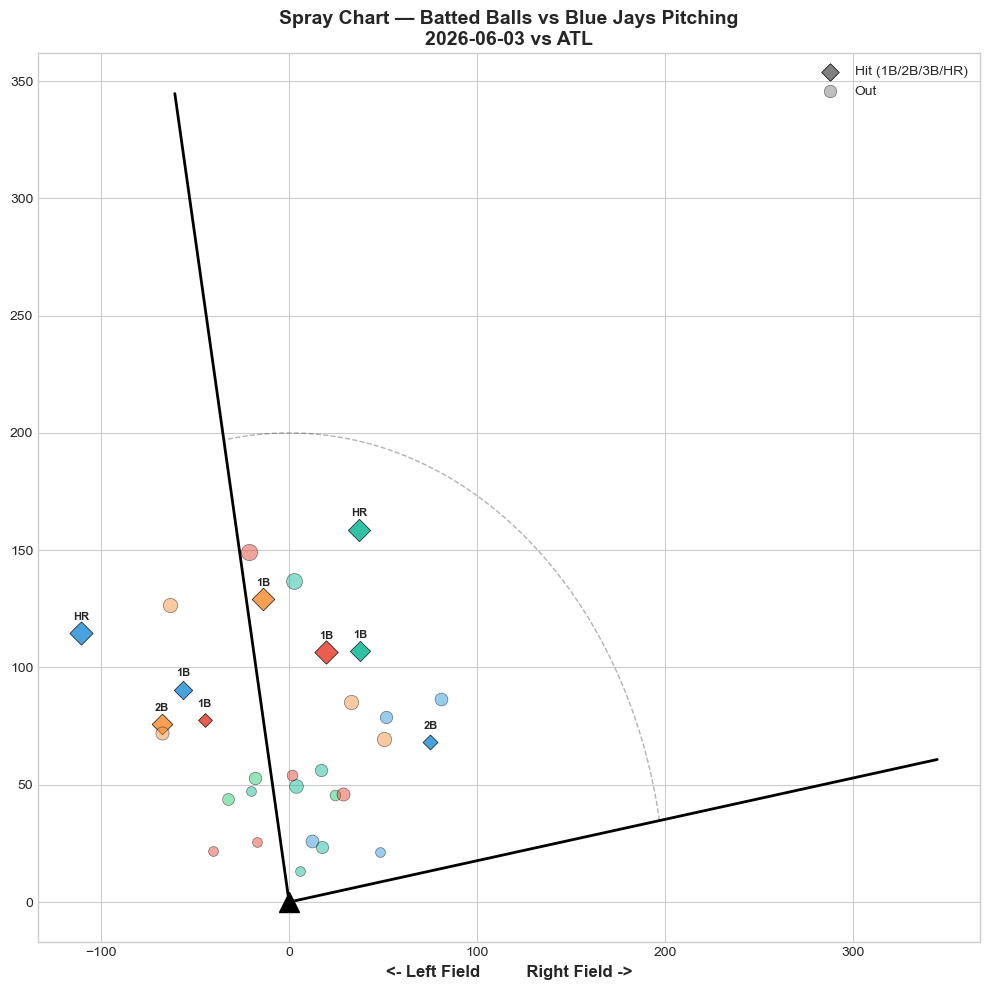


=== Spray Summary ===
Total batted balls tracked: 31
Hits: 9 (29%)
Pull: 5 (16%) | Center: 19 (61%) | Oppo: 7 (23%)


In [36]:
spray_data = jays_pitchers.dropna(subset=['hc_x', 'hc_y']).copy()

if len(spray_data) > 0:
    fig, ax = plt.subplots(figsize=(10, 10))

    spray_data['spray_x'] = spray_data['hc_x'] - 125.42
    spray_data['spray_y'] = 198.28 - spray_data['hc_y']

    theta1 = np.radians(10)
    theta2 = np.radians(100)

    ax.plot([0, 0 + np.cos(theta1) * 350], [0, 0 + np.sin(theta1) * 350], 'k-', linewidth=2)
    ax.plot([0, 0 + np.cos(theta2) * 350], [0, 0 + np.sin(theta2) * 350], 'k-', linewidth=2)

    arc_angles = np.linspace(theta1, theta2, 100)
    ax.plot(200 * np.cos(arc_angles), 200 * np.sin(arc_angles), 'k--', alpha=0.3, linewidth=1)

    ax.plot(0, 0, marker='^', markersize=15, color='black')

    for _, row in spray_data.iterrows():
        event = row.get('events', '')
        pt = row.get('pitch_type', '')
        ev = row.get('launch_speed', 0)

        color = PITCH_COLORS.get(pt, '#95a5a6')
        if pt == '':
            continue

        ev_val = ev if pd.notna(ev) else 0
        size = max(50, min(200, (ev_val - 60) * 3))

        if event in ['single', 'double', 'triple', 'home_run']:
            marker = 'D'
            alpha = 0.9
        else:
            marker = 'o'
            alpha = 0.5

        ax.scatter(row['spray_x'], row['spray_y'], color=color, marker=marker,
                  s=size, alpha=alpha, edgecolors='black', linewidth=0.5)

        if event in ['single', 'double', 'triple', 'home_run']:
            label = '1B' if event == 'single' else '2B' if event == 'double' else '3B' if event == 'triple' else 'HR'
            ax.annotate(label, (row['spray_x'], row['spray_y']),
                       fontsize=8, fontweight='bold', ha='center', va='bottom',
                       xytext=(0, 8), textcoords='offset points')

    hit_marker = ax.scatter([], [], color='gray', marker='D', s=80, edgecolors='black', linewidth=0.5, label='Hit (1B/2B/3B/HR)')
    out_marker = ax.scatter([], [], color='gray', marker='o', s=80, alpha=0.5, edgecolors='black', linewidth=0.5, label='Out')
    ax.legend(fontsize=10, loc='upper right')

    ax.set_xlabel('<- Left Field          Right Field ->', fontsize=12, fontweight='bold')
    ax.set_title('Spray Chart — Batted Balls vs Blue Jays Pitching\n' + GAME_DATE + ' vs ' + OPPONENT,
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../visualizations/spray_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    total_bip = len(spray_data)
    hits_list = spray_data[spray_data['events'].isin(['single', 'double', 'triple', 'home_run'])]
    hit_pct = round(len(hits_list) / total_bip * 100) if total_bip > 0 else 0

    pull = spray_data[(spray_data['spray_x'] > 40)]
    center = spray_data[(spray_data['spray_x'] >= -40) & (spray_data['spray_x'] <= 40)]
    oppo = spray_data[(spray_data['spray_x'] < -40)]

    print("\n=== Spray Summary ===")
    print("Total batted balls tracked: " + str(total_bip))
    print("Hits: " + str(len(hits_list)) + " (" + str(hit_pct) + "%)")
    print("Pull: " + str(len(pull)) + " (" + str(round(len(pull)/total_bip*100)) + "%) | Center: " + str(len(center)) + " (" + str(round(len(center)/total_bip*100)) + "%) | Oppo: " + str(len(oppo)) + " (" + str(round(len(oppo)/total_bip*100)) + "%)")
else:
    print("No spray chart data available.")


=== Corbin, Patrick — Pitch Run Value by Inning ===
Chart saved!


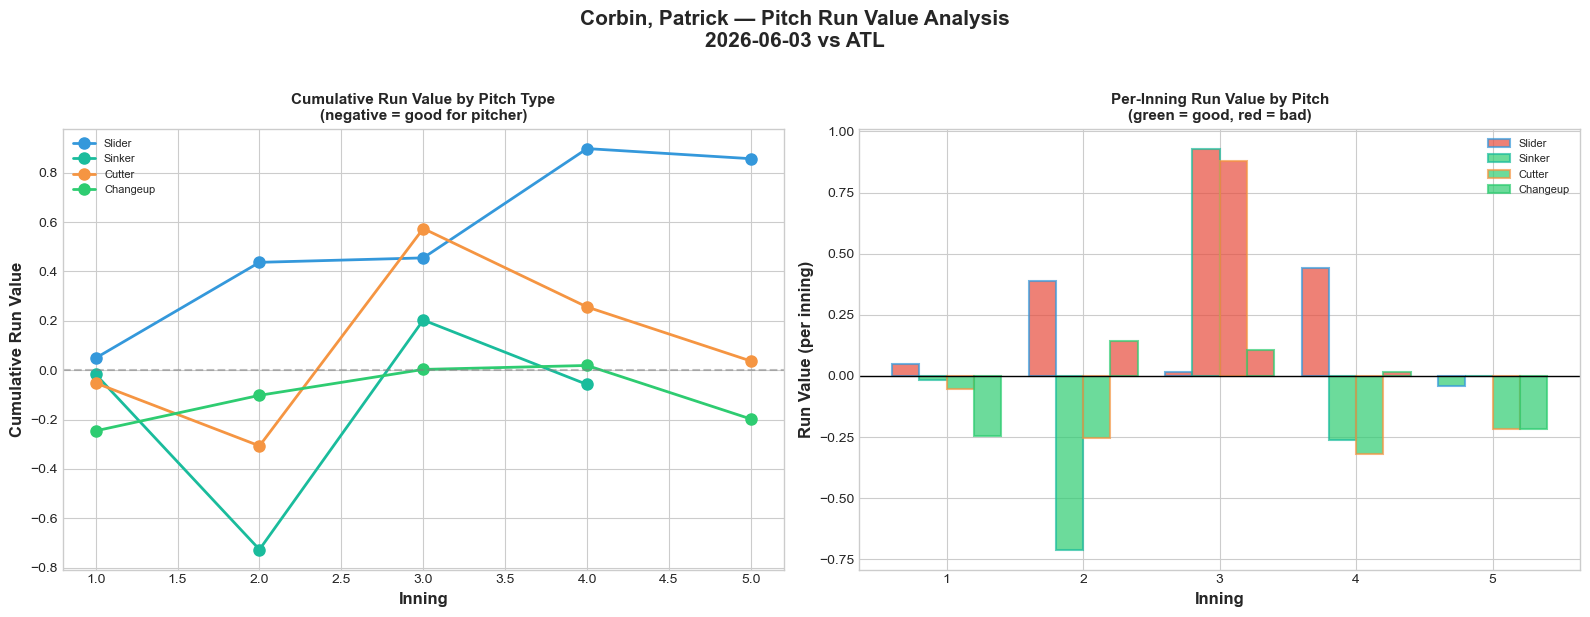


=== Total Run Value by Pitch Type ===
  🔴 Slider: 0.857 total RV (0.0451 per pitch, 19 pitches)
  🟡 Sinker: -0.058 total RV (-0.0032 per pitch, 18 pitches)
  🟡 Cutter: 0.037 total RV (0.0022 per pitch, 17 pitches)
  🟢 Changeup: -0.198 total RV (-0.0124 per pitch, 16 pitches)
  🔴 4-Seam: 0.249 total RV (0.0192 per pitch, 13 pitches)
  🟡 Curveball: -0.086 total RV (-0.043 per pitch, 2 pitches)

🏆 Most Effective: Changeup
⚠️ Least Effective: Slider


In [37]:
print("\n=== " + STARTER_NAME + " — Pitch Run Value by Inning ===")

rv_data = starter.dropna(subset=['delta_run_exp']).copy()

if len(rv_data) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    ax1 = axes[0]
    for pt in rv_data['pitch_type'].value_counts().head(4).index:
        pt_data = rv_data[rv_data['pitch_type'] == pt].copy()
        pt_data = pt_data.sort_values(['inning', 'at_bat_number', 'pitch_number'])
        pt_data['cum_rv'] = pt_data['delta_run_exp'].cumsum()
        inning_rv = pt_data.groupby('inning')['cum_rv'].last()
        ax1.plot(inning_rv.index, inning_rv.values, '-o',
                color=PITCH_COLORS.get(pt, '#95a5a6'), linewidth=2, markersize=8,
                label=PITCH_NAMES.get(pt, pt))

    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Inning', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Cumulative Run Value', fontsize=12, fontweight='bold')
    ax1.set_title('Cumulative Run Value by Pitch Type\n(negative = good for pitcher)',
                 fontsize=11, fontweight='bold')
    ax1.legend(fontsize=8)

    ax2 = axes[1]
    inning_list = sorted(rv_data['inning'].unique())
    pitch_types_top = rv_data['pitch_type'].value_counts().head(4).index.tolist()
    bar_width = 0.8 / len(pitch_types_top)

    for idx, pt in enumerate(pitch_types_top):
        pt_rv = rv_data[rv_data['pitch_type'] == pt].groupby('inning')['delta_run_exp'].sum()
        positions = [inn + (idx - len(pitch_types_top)/2 + 0.5) * bar_width for inn in inning_list]
        values = [pt_rv.get(inn, 0) for inn in inning_list]
        colors_bar = ['#2ecc71' if v <= 0 else '#e74c3c' for v in values]
        ax2.bar(positions, values, bar_width, color=colors_bar, alpha=0.7,
               edgecolor=PITCH_COLORS.get(pt, '#95a5a6'), linewidth=1.5,
               label=PITCH_NAMES.get(pt, pt))

    ax2.axhline(y=0, color='black', linewidth=1)
    ax2.set_xlabel('Inning', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Run Value (per inning)', fontsize=12, fontweight='bold')
    ax2.set_title('Per-Inning Run Value by Pitch\n(green = good, red = bad)', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.set_xticks(inning_list)

    plt.suptitle(STARTER_NAME + ' — Pitch Run Value Analysis\n' + GAME_DATE + ' vs ' + OPPONENT,
                fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../visualizations/runvalue_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
    print("Chart saved!")
    plt.show()

    print("\n=== Total Run Value by Pitch Type ===")
    for pt in rv_data['pitch_type'].value_counts().index:
        total_rv = rv_data[rv_data['pitch_type'] == pt]['delta_run_exp'].sum()
        count = len(rv_data[rv_data['pitch_type'] == pt])
        per_pitch = total_rv / count if count > 0 else 0
        if total_rv <= -0.1: emoji = "🟢"
        elif total_rv <= 0.1: emoji = "🟡"
        else: emoji = "🔴"
        print("  " + emoji + " " + PITCH_NAMES.get(pt, pt) + ": " + str(round(total_rv, 3)) + " total RV (" + str(round(per_pitch, 4)) + " per pitch, " + str(count) + " pitches)")

    best_pitch = rv_data.groupby('pitch_type')['delta_run_exp'].sum().idxmin()
    worst_pitch = rv_data.groupby('pitch_type')['delta_run_exp'].sum().idxmax()
    print("\n🏆 Most Effective: " + PITCH_NAMES.get(best_pitch, best_pitch))
    print("⚠️ Least Effective: " + PITCH_NAMES.get(worst_pitch, worst_pitch))
else:
    print("Run value data not available.")

In [38]:
if SEASON_RS > 0 and SEASON_RA > 0:
    game_rs = int(RESULT.split('-')[0].split()[-1]) if 'W' in RESULT else int(RESULT.split('-')[1])
    game_ra = int(RESULT.split('-')[1]) if 'W' in RESULT else int(RESULT.split('-')[0].split()[-1])
    new_rs = SEASON_RS + game_rs
    new_ra = SEASON_RA + game_ra
    total_games = SEASON_W + SEASON_L
    pyth = new_rs**2 / (new_rs**2 + new_ra**2)
    pyth_w = round(pyth * total_games)
    pyth_l = total_games - pyth_w

    print("Actual: " + str(SEASON_W) + "W-" + str(SEASON_L) + "L")
    print("Pythagorean: " + str(pyth_w) + "W-" + str(pyth_l) + "L")
    diff = SEASON_W - pyth_w
    if diff > 0:
        print("OVERPERFORMING by +" + str(diff) + " wins")
    elif diff < 0:
        print("UNDERPERFORMING by " + str(diff) + " wins")
    else:
        print("Record matches run differential perfectly")
else:
    print("Enter SEASON_RS and SEASON_RA in Cell 1 to enable Pythagorean tracker.")

Enter SEASON_RS and SEASON_RA in Cell 1 to enable Pythagorean tracker.


In [39]:
print("=== BULLPEN DETAILED ANALYSIS ===\n")

all_pitchers = jays_pitchers['player_name'].unique()
bullpen_pitchers = [p for p in all_pitchers if p != STARTER_NAME]

for bp_name in bullpen_pitchers:
    bp_data = jays_pitchers[jays_pitchers['player_name'] == bp_name]
    if len(bp_data) < 3:
        continue

    print("=" * 55)
    print("  " + bp_name + " — " + str(len(bp_data)) + " pitches")
    print("=" * 55)

    print("{:<12} {:>4} {:>7} {:>7} {:>7} {:>7}".format(
        'Pitch', '#', 'Usage', 'Velo', 'Whiff%', 'CSW%'))
    print("-" * 55)

    for pt in bp_data['pitch_type'].value_counts().index:
        pt_data = bp_data[bp_data['pitch_type'] == pt]
        count = len(pt_data)
        usage = count / len(bp_data) * 100
        avg_velo = pt_data['release_speed'].mean()

        swinging = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked'])
        swings = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                               'foul', 'foul_tip', 'hit_into_play',
                                               'hit_into_play_no_out', 'hit_into_play_score'])
        whiff_rate = (swinging.sum() / swings.sum() * 100) if swings.sum() > 0 else 0

        called = pt_data['description'].isin(['called_strike']).sum()
        csw = (swinging.sum() + called) / count * 100

        if whiff_rate >= 30: grade = '🟢 A'
        elif whiff_rate >= 20: grade = '🟢 B'
        elif whiff_rate >= 10: grade = '🟡 C'
        else: grade = '🔴 D'

        print("{:<12} {:>4} {:>6.1f}% {:>6.1f} {:>6.1f}% {:>6.1f}% {:>7}".format(
            PITCH_NAMES.get(pt, pt), count, usage, avg_velo, whiff_rate, csw, grade))

    ks = (bp_data['events'] == 'strikeout').sum()
    bbs = bp_data['events'].isin(['walk', 'hit_by_pitch']).sum()
    hits = bp_data['events'].isin(['single', 'double', 'triple', 'home_run']).sum()
    hrs = (bp_data['events'] == 'home_run').sum()
    total_swinging = bp_data['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
    total_swings = bp_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                                 'foul', 'foul_tip', 'hit_into_play',
                                                 'hit_into_play_no_out', 'hit_into_play_score']).sum()
    whiff_total = (total_swinging / total_swings * 100) if total_swings > 0 else 0

    print("\n  Summary: " + str(ks) + "K / " + str(bbs) + "BB / " + str(hits) + "H / " + str(hrs) + "HR | Whiff rate: " + str(round(whiff_total, 1)) + "%\n")

=== BULLPEN DETAILED ANALYSIS ===

  Juenger, Hayden — 11 pitches
Pitch           #   Usage    Velo  Whiff%    CSW%
-------------------------------------------------------
Slider          6   54.5%   88.1    0.0%   66.7%     🔴 D
4-Seam          3   27.3%   95.0    0.0%   33.3%     🔴 D
Changeup        2   18.2%   88.7    0.0%    0.0%     🔴 D

  Summary: 0K / 0BB / 0H / 0HR | Whiff rate: 0.0%

  Macko, Adam — 17 pitches
Pitch           #   Usage    Velo  Whiff%    CSW%
-------------------------------------------------------
Slider         10   58.8%   85.6   20.0%   30.0%     🟢 B
4-Seam          4   23.5%   94.1    0.0%    0.0%     🔴 D
Changeup        2   11.8%   85.9    0.0%    0.0%     🔴 D
K-Curve         1    5.9%   79.6    0.0%  100.0%     🔴 D

  Summary: 0K / 0BB / 2H / 1HR | Whiff rate: 14.3%

  Rodríguez, Yariel — 22 pitches
Pitch           #   Usage    Velo  Whiff%    CSW%
-------------------------------------------------------
Slider         10   45.5%   85.7    0.0%   30.0%    

In [40]:
if SPOTLIGHT_PITCHER:
    spotlight = jays_pitchers[jays_pitchers['player_name'] == SPOTLIGHT_PITCHER]

    if len(spotlight) > 0:
        print("=" * 70)
        print("  🔎 PITCHER SPOTLIGHT: " + SPOTLIGHT_PITCHER)
        print("  " + str(len(spotlight)) + " pitches this game")
        print("=" * 70)

        print("\n--- Pitch Arsenal ---")
        print("{:<12} {:>4} {:>7} {:>7} {:>7} {:>7}".format(
            'Pitch', '#', 'Usage', 'Velo', 'Whiff%', 'CSW%'))
        print("-" * 55)

        for pt in spotlight['pitch_type'].value_counts().index:
            pt_data = spotlight[spotlight['pitch_type'] == pt]
            count = len(pt_data)
            usage = count / len(spotlight) * 100
            avg_velo = pt_data['release_speed'].mean()

            swinging = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked'])
            swings = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                                   'foul', 'foul_tip', 'hit_into_play',
                                                   'hit_into_play_no_out', 'hit_into_play_score'])
            whiff_rate = (swinging.sum() / swings.sum() * 100) if swings.sum() > 0 else 0

            called = pt_data['description'].isin(['called_strike']).sum()
            csw = (swinging.sum() + called) / count * 100

            if whiff_rate >= 30: grade = '🟢 A'
            elif whiff_rate >= 20: grade = '🟢 B'
            elif whiff_rate >= 10: grade = '🟡 C'
            else: grade = '🔴 D'

            print("{:<12} {:>4} {:>6.1f}% {:>6.1f} {:>6.1f}% {:>6.1f}% {:>7}".format(
                PITCH_NAMES.get(pt, pt), count, usage, avg_velo, whiff_rate, csw, grade))

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        ax1 = axes[0]
        for pt in spotlight['pitch_type'].value_counts().index:
            pt_data = spotlight[spotlight['pitch_type'] == pt]
            ax1.scatter(pt_data['pfx_x'] * 12, pt_data['pfx_z'] * 12,
                       color=PITCH_COLORS.get(pt, '#95a5a6'), s=60, alpha=0.7,
                       label=PITCH_NAMES.get(pt, pt) + ' (' + str(len(pt_data)) + ')')
        ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
        ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        ax1.set_xlabel('H-Break (in)')
        ax1.set_ylabel('V-Break (in)')
        ax1.set_title('Movement Profile')
        ax1.legend(fontsize=8)

        ax2 = axes[1]
        zone = plt.Rectangle((-0.83, 1.5), 1.66, 2.0, fill=False, edgecolor='black', linewidth=2)
        ax2.add_patch(zone)
        for _, row in spotlight.iterrows():
            if pd.notna(row['plate_x']) and pd.notna(row['plate_z']):
                pt = row['pitch_type']
                color = PITCH_COLORS.get(pt, '#95a5a6')
                if row['description'] in ['swinging_strike', 'swinging_strike_blocked']:
                    marker = 'X'
                    alpha = 0.9
                elif row['description'] == 'called_strike':
                    marker = 'D'
                    alpha = 0.8
                else:
                    marker = 'o'
                    alpha = 0.5
                ax2.scatter(row['plate_x'], row['plate_z'], color=color, marker=marker,
                           s=80, alpha=alpha, edgecolors='black', linewidth=0.5)
        ax2.set_xlim(-2, 2)
        ax2.set_ylim(0.5, 4.5)
        ax2.set_xlabel('Horizontal (ft)')
        ax2.set_ylabel('Vertical (ft)')
        ax2.set_title('Zone Location + Whiffs (X)')

        ax3 = axes[2]
        for pt in spotlight['pitch_type'].value_counts().head(3).index:
            pt_data = spotlight[spotlight['pitch_type'] == pt]['release_speed'].dropna()
            if len(pt_data) >= 2:
                try:
                    kde = gaussian_kde(pt_data)
                    x_range = np.linspace(pt_data.min() - 3, pt_data.max() + 3, 200)
                    ax3.plot(x_range, kde(x_range), color=PITCH_COLORS.get(pt, '#95a5a6'),
                            label=PITCH_NAMES.get(pt, pt) + ' (' + str(round(pt_data.mean(), 1)) + ')',
                            linewidth=2)
                    ax3.fill_between(x_range, kde(x_range), alpha=0.15, color=PITCH_COLORS.get(pt, '#95a5a6'))
                except:
                    pass
        ax3.set_xlabel('Velocity (mph)')
        ax3.set_title('Velocity KDE')
        ax3.legend(fontsize=8)

        fig.suptitle('🔎 SPOTLIGHT: ' + SPOTLIGHT_PITCHER + '\n' + GAME_DATE + ' vs ' + OPPONENT,
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('../visualizations/spotlight_' + GAME_DATE + '.png', dpi=150, bbox_inches='tight')
        print("Chart saved!")
        plt.show()

        sp_ks = (spotlight['events'] == 'strikeout').sum()
        sp_bb = spotlight['events'].isin(['walk', 'hit_by_pitch']).sum()
        sp_hits = spotlight['events'].isin(['single', 'double', 'triple', 'home_run']).sum()
        print("\n--- Game Summary ---")
        print("  K: " + str(sp_ks) + " | BB: " + str(sp_bb) + " | H: " + str(sp_hits))

        sp_sw = spotlight['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
        sp_swings = spotlight['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                                    'foul', 'foul_tip', 'hit_into_play',
                                                    'hit_into_play_no_out', 'hit_into_play_score']).sum()
        sp_whiff = (sp_sw / sp_swings * 100) if sp_swings > 0 else 0

        print("\n--- Role Assessment ---")
        if sp_whiff >= 30:
            print("  🔥 ELITE RELIEVER: High whiff rate (" + str(round(sp_whiff, 1)) + "%)")
        elif sp_whiff >= 15:
            print("  ✅ SOLID RELIEVER: Moderate whiff rate (" + str(round(sp_whiff, 1)) + "%)")
        else:
            print("  📋 CONTACT MANAGER: Low whiff rate (" + str(round(sp_whiff, 1)) + "%)")
    else:
        print("SPOTLIGHT_PITCHER '" + SPOTLIGHT_PITCHER + "' not found in pitching data.")
        print("Available pitchers:")
        for name in jays_pitchers['player_name'].unique():
            print("  " + name)
else:
    print("No spotlight pitcher for this game.")

No spotlight pitcher for this game.


In [41]:
game_data.to_csv('../data/game_' + GAME_DATE + '.csv', index=False)
print("Game data saved: " + str(len(game_data)) + " pitches")

print("\n" + "=" * 60)
print("  REPORT v2.1 COMPLETE — " + GAME_DATE + " vs " + OPPONENT)
print("  Charts saved to ../visualizations/:")
charts = ['movement', 'zone', 'batted_balls', 'velocity', 'release', 'gamescore', 'wpa', 'spray', 'runvalue']
if SPOTLIGHT_PITCHER:
    charts.append('spotlight')
for c in charts:
    print("    " + c + "_" + GAME_DATE + ".png")
print("=" * 60)

Game data saved: 4469 pitches

  REPORT v2.1 COMPLETE — 2026-06-03 vs ATL
  Charts saved to ../visualizations/:
    movement_2026-06-03.png
    zone_2026-06-03.png
    batted_balls_2026-06-03.png
    velocity_2026-06-03.png
    release_2026-06-03.png
    gamescore_2026-06-03.png
    wpa_2026-06-03.png
    spray_2026-06-03.png
    runvalue_2026-06-03.png


In [42]:
import io
import sys

output = io.StringIO()
old_stdout = sys.stdout
sys.stdout = output

print("=== BLUE JAYS GAME REPORT DATA EXPORT ===")
print("Date: " + GAME_DATE)
print("Opponent: " + OPPONENT)
print("Result: " + RESULT)
print("Starter: " + STARTER_NAME)
print("Spotlight: " + (SPOTLIGHT_PITCHER if SPOTLIGHT_PITCHER else "None"))
print("Season Record: " + str(SEASON_W) + "-" + str(SEASON_L))
print("Home/Away: " + HOME_AWAY)
print("")

print("=== DATA SUMMARY ===")
print("Total pitches in game: " + str(len(game_data)))
print("Blue Jays pitching data: " + str(len(jays_pitchers)) + " pitches")
print("Blue Jays batting data: " + str(len(jays_batting)) + " pitches")
print(STARTER_NAME + ": " + str(len(starter)) + " pitches")
print("")

print("=== All Blue Jays pitchers ===")
for name in jays_pitchers['player_name'].unique():
    count = len(jays_pitchers[jays_pitchers['player_name'] == name])
    print("  " + name + ": " + str(count) + " pitches")
print("")

print("=== STARTER PITCH ARSENAL ===")
print("{:<12} {:>4} {:>7} {:>7} {:>7} {:>7} {:>8} {:>7}".format(
    'Pitch', '#', 'Usage', 'Velo', 'Whiff%', 'CSW%', 'Chase%', 'Grade'))
print("-" * 70)
for pt in starter['pitch_type'].value_counts().index:
    pt_data = starter[starter['pitch_type'] == pt]
    count = len(pt_data)
    usage = count / len(starter) * 100
    avg_velo = pt_data['release_speed'].mean()
    swinging = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked'])
    swings = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                           'foul', 'foul_tip', 'hit_into_play',
                                           'hit_into_play_no_out', 'hit_into_play_score'])
    whiff_rate = (swinging.sum() / swings.sum() * 100) if swings.sum() > 0 else 0
    called = pt_data['description'].isin(['called_strike']).sum()
    csw = (swinging.sum() + called) / count * 100
    outside_zone = pt_data[(pt_data['plate_x'].abs() > 0.83) |
                           (pt_data['plate_z'] < 1.5) |
                           (pt_data['plate_z'] > 3.5)]
    chases = outside_zone['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                                'foul', 'foul_tip', 'hit_into_play',
                                                'hit_into_play_no_out', 'hit_into_play_score'])
    chase_rate = (chases.sum() / len(outside_zone) * 100) if len(outside_zone) > 0 else 0
    if whiff_rate >= 30: grade = 'A'
    elif whiff_rate >= 20: grade = 'B'
    elif whiff_rate >= 10: grade = 'C'
    else: grade = 'D'
    print("{:<12} {:>4} {:>6.1f}% {:>6.1f} {:>6.1f}% {:>6.1f}% {:>7.1f}% {:>7}".format(
        PITCH_NAMES.get(pt, pt), count, usage, avg_velo, whiff_rate, csw, chase_rate, grade))
print("")

print("=== PITCH MOVEMENT (inches) ===")
for pt in starter['pitch_type'].value_counts().index:
    pt_data = starter[starter['pitch_type'] == pt]
    if len(pt_data) >= 2:
        h = pt_data['pfx_x'].mean() * 12
        v = pt_data['pfx_z'].mean() * 12
        print("  " + PITCH_NAMES.get(pt, pt) + ": H=" + str(round(h, 1)) + " V=" + str(round(v, 1)) + " (" + str(len(pt_data)) + " pitches)")
print("")

print("=== vs LHB/RHB ===")
for stand in ['L', 'R']:
    s_data = starter[starter['stand'] == stand]
    if len(s_data) > 0:
        sw = s_data['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
        whiff_pp = sw / len(s_data) * 100
        print("  " + stand + ": " + str(len(s_data)) + " pitches, avg velo " + str(round(s_data['release_speed'].mean(), 1)) + ", " + str(sw) + " swinging strikes, whiff/pitch " + str(round(whiff_pp, 1)) + "%")
print("")

print("=== PITCH SELECTION BY COUNT ===")
count_groups_export = {
    'First pitch (0-0)': starter[(starter['balls'] == 0) & (starter['strikes'] == 0)],
    'Ahead': starter[((starter['balls'] == 0) & (starter['strikes'].isin([1,2]))) |
                      ((starter['balls'] == 1) & (starter['strikes'] == 2))],
    'Behind': starter[((starter['balls'].isin([1,2,3])) & (starter['strikes'] == 0)) |
                       ((starter['balls'].isin([2,3])) & (starter['strikes'] == 1))],
    'Even': starter[((starter['balls'] == 1) & (starter['strikes'] == 1)) |
                     ((starter['balls'] == 2) & (starter['strikes'] == 2))],
    'Full count (3-2)': starter[(starter['balls'] == 3) & (starter['strikes'] == 2)]
}
for situation, data in count_groups_export.items():
    if len(data) > 0:
        print("  " + situation + " (" + str(len(data)) + " pitches):")
        for pt in data['pitch_type'].value_counts().index:
            pct = len(data[data['pitch_type'] == pt]) / len(data) * 100
            print("    " + PITCH_NAMES.get(pt, pt) + ": " + str(round(pct, 1)) + "%")
print("")

k_data = starter[starter['events'] == 'strikeout']
print("=== STRIKEOUT PITCHES (" + str(len(k_data)) + " K's) ===")
for pt in k_data['pitch_type'].value_counts().index:
    print("  " + PITCH_NAMES.get(pt, pt) + ": " + str(k_data['pitch_type'].value_counts()[pt]))
print("")

print("=== TOP OPPOSING BATTERS ===")
batter_stats_export = starter.groupby('batter').agg(
    pitches=('pitch_type', 'count'),
    hits=('events', lambda x: x.isin(['single', 'double', 'triple', 'home_run']).sum()),
    strikeouts=('events', lambda x: (x == 'strikeout').sum()),
    walks=('events', lambda x: (x == 'walk').sum()),
    avg_exit_velo=('launch_speed', 'mean')
).round(1).sort_values('pitches', ascending=False).head(5)
try:
    batter_ids_export = batter_stats_export.index.tolist()
    batter_names_export = playerid_reverse_lookup(batter_ids_export, key_type='mlbam')
    batter_names_export['full_name'] = batter_names_export['name_last'] + ', ' + batter_names_export['name_first']
    name_map_export = dict(zip(batter_names_export['key_mlbam'], batter_names_export['full_name']))
except:
    name_map_export = {}
for bid, row in batter_stats_export.iterrows():
    bname = name_map_export.get(bid, str(bid))
    print("  " + bname + ": " + str(int(row['pitches'])) + " pitches, " + str(int(row['hits'])) + " hits, " + str(int(row['strikeouts'])) + " K, " + str(int(row['walks'])) + " BB, avg EV " + str(row['avg_exit_velo']))
print("")

print("=== BATTED BALL SUMMARY ===")
batted_export = starter.dropna(subset=['launch_speed', 'launch_angle'])
print("Total BIP: " + str(len(batted_export)))
if len(batted_export) > 0:
    print("Avg EV: " + str(round(batted_export['launch_speed'].mean(), 1)) + " mph")
    print("Avg LA: " + str(round(batted_export['launch_angle'].mean(), 1)))
    hh = (batted_export['launch_speed'] >= 95).sum()
    print("Hard hit (95+): " + str(hh) + "/" + str(len(batted_export)) + " (" + str(round(hh/len(batted_export)*100)) + "%)")
print("")

print("=== VELOCITY TREND ===")
for pt in starter['pitch_type'].value_counts().head(3).index:
    pt_data = starter[starter['pitch_type'] == pt]
    iv = pt_data.groupby('inning')['release_speed'].mean()
    if len(iv) >= 2:
        print("  " + PITCH_NAMES.get(pt, pt) + ": " + str(round(iv.iloc[0], 1)) + " -> " + str(round(iv.iloc[-1], 1)) + " mph (" + ("+" if iv.iloc[-1]-iv.iloc[0] >= 0 else "") + str(round(iv.iloc[-1]-iv.iloc[0], 1)) + ")")
print("")

print("=== RELEASE POINT SPREAD ===")
for pt in starter['pitch_type'].value_counts().head(5).index:
    pt_data = starter[starter['pitch_type'] == pt]
    if len(pt_data) >= 3:
        h_s = pt_data['release_pos_x'].std() * 12
        v_s = pt_data['release_pos_z'].std() * 12
        total = np.sqrt(h_s**2 + v_s**2)
        rating = "Tight" if total < 3.0 else "Moderate" if total < 5.0 else "Wide"
        print("  " + PITCH_NAMES.get(pt, pt) + ": H=" + str(round(h_s, 1)) + "in V=" + str(round(v_s, 1)) + "in Total=" + str(round(total, 1)) + "in " + rating)
print("")

print("=== TUNNELING ANALYSIS ===")
for t in tunnel_results:
    rating = "GREEN" if t['tunnel'] >= 3.0 else "YELLOW" if t['tunnel'] >= 2.0 else "RED"
    print("  " + t['pair'] + ": RelSim=" + str(round(t['release_sim'], 1)) + "in PlateSep=" + str(round(t['plate_sep'], 1)) + "in Tunnel=" + str(round(t['tunnel'], 1)) + " (" + rating + ") VeloGap=" + str(round(t['velo_gap'], 1)) + "mph")
if len(tunnel_results) > 0:
    print("Best Tunnel: " + tunnel_results[0]['pair'] + " (score: " + str(round(tunnel_results[0]['tunnel'], 1)) + ")")
print("")

print("=== GAME SCORE ===")
print("Game Score: " + str(gs))
print("K: " + str(ks) + " H: " + str(hits) + " HR: " + str(hrs) + " BB/HBP: " + str(walks_hbp))
print("")

print("=== KEY WPA MOMENTS ===")
if 'delta_home_win_exp' in game_data.columns:
    wpa_data_export = game_data.dropna(subset=['delta_home_win_exp']).copy()
    wpa_data_export['delta_home_win_exp'] = wpa_data_export['delta_home_win_exp'].astype(float)
    if HOME_AWAY == 'AWAY':
        wpa_data_export['tor_wp'] = 1 - wpa_data_export['delta_home_win_exp'].cumsum()
    else:
        wpa_data_export['tor_wp'] = wpa_data_export['delta_home_win_exp'].cumsum()
    wpa_data_export['tor_wp'] = wpa_data_export['tor_wp'] * 100
    top_m = wpa_data_export.nlargest(3, 'delta_home_win_exp')
    bot_m = wpa_data_export.nsmallest(3, 'delta_home_win_exp')
    key_m = pd.concat([top_m, bot_m])
    for _, row in key_m.iterrows():
        d = "UP" if row['delta_home_win_exp'] > 0 else "DOWN"
        print("  " + d + " Inn " + str(int(row['inning'])) + ": " + str(row.get('player_name', '')) + " — " + str(row.get('events', '')) + " (WP " + str(round(row['tor_wp'], 1)) + "%)")
print("")

print("=== SPRAY SUMMARY ===")
spray_export = jays_pitchers.dropna(subset=['hc_x', 'hc_y'])
spray_export_copy = spray_export.copy()
spray_export_copy['spray_x'] = spray_export_copy['hc_x'] - 125.42
total_bip_spray = len(spray_export_copy)
if total_bip_spray > 0:
    hits_spray = spray_export_copy[spray_export_copy['events'].isin(['single', 'double', 'triple', 'home_run'])]
    print("Total batted balls: " + str(total_bip_spray))
    print("Hits: " + str(len(hits_spray)) + " (" + str(round(len(hits_spray)/total_bip_spray*100)) + "%)")
    pull_s = len(spray_export_copy[spray_export_copy['spray_x'] > 40])
    center_s = len(spray_export_copy[(spray_export_copy['spray_x'] >= -40) & (spray_export_copy['spray_x'] <= 40)])
    oppo_s = len(spray_export_copy[spray_export_copy['spray_x'] < -40])
    print("Pull: " + str(pull_s) + " Center: " + str(center_s) + " Oppo: " + str(oppo_s))
print("")

print("=== PITCH RUN VALUE ===")
rv_export = starter.dropna(subset=['delta_run_exp'])
if len(rv_export) > 0:
    for pt in rv_export['pitch_type'].value_counts().index:
        t_rv = rv_export[rv_export['pitch_type'] == pt]['delta_run_exp'].sum()
        cnt = len(rv_export[rv_export['pitch_type'] == pt])
        pp = t_rv / cnt if cnt > 0 else 0
        print("  " + PITCH_NAMES.get(pt, pt) + ": " + str(round(t_rv, 3)) + " total (" + str(round(pp, 4)) + " per pitch, " + str(cnt) + " pitches)")
    best_p = rv_export.groupby('pitch_type')['delta_run_exp'].sum().idxmin()
    worst_p = rv_export.groupby('pitch_type')['delta_run_exp'].sum().idxmax()
    print("Most Effective: " + PITCH_NAMES.get(best_p, best_p))
    print("Least Effective: " + PITCH_NAMES.get(worst_p, worst_p))
print("")

print("=== BULLPEN DETAILED ===")
for bp_name in bullpen_pitchers:
    bp_data = jays_pitchers[jays_pitchers['player_name'] == bp_name]
    if len(bp_data) < 3:
        continue
    print(bp_name + " — " + str(len(bp_data)) + " pitches")
    for pt in bp_data['pitch_type'].value_counts().index:
        pt_data = bp_data[bp_data['pitch_type'] == pt]
        cnt = len(pt_data)
        usg = cnt / len(bp_data) * 100
        velo = pt_data['release_speed'].mean()
        sw = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked'])
        swgs = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                             'foul', 'foul_tip', 'hit_into_play',
                                             'hit_into_play_no_out', 'hit_into_play_score'])
        wr = (sw.sum() / swgs.sum() * 100) if swgs.sum() > 0 else 0
        cal = pt_data['description'].isin(['called_strike']).sum()
        cs = (sw.sum() + cal) / cnt * 100
        if wr >= 30: g = 'A'
        elif wr >= 20: g = 'B'
        elif wr >= 10: g = 'C'
        else: g = 'D'
        print("  " + PITCH_NAMES.get(pt, pt) + ": " + str(cnt) + " (" + str(round(usg, 1)) + "%) velo=" + str(round(velo, 1)) + " whiff=" + str(round(wr, 1)) + "% csw=" + str(round(cs, 1)) + "% grade=" + g)
    bk = (bp_data['events'] == 'strikeout').sum()
    bb = bp_data['events'].isin(['walk', 'hit_by_pitch']).sum()
    bh = bp_data['events'].isin(['single', 'double', 'triple', 'home_run']).sum()
    bhr = (bp_data['events'] == 'home_run').sum()
    print("  Line: " + str(bk) + "K / " + str(bb) + "BB / " + str(bh) + "H / " + str(bhr) + "HR")
    print("")

print("=== SPOTLIGHT PITCHER ===")
if SPOTLIGHT_PITCHER:
    spotlight_export = jays_pitchers[jays_pitchers['player_name'] == SPOTLIGHT_PITCHER]
    if len(spotlight_export) > 0:
        print(SPOTLIGHT_PITCHER + " — " + str(len(spotlight_export)) + " pitches")
        for pt in spotlight_export['pitch_type'].value_counts().index:
            pt_data = spotlight_export[spotlight_export['pitch_type'] == pt]
            cnt = len(pt_data)
            usg = cnt / len(spotlight_export) * 100
            velo = pt_data['release_speed'].mean()
            sw = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked'])
            swgs = pt_data['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                                 'foul', 'foul_tip', 'hit_into_play',
                                                 'hit_into_play_no_out', 'hit_into_play_score'])
            wr = (sw.sum() / swgs.sum() * 100) if swgs.sum() > 0 else 0
            cal = pt_data['description'].isin(['called_strike']).sum()
            cs = (sw.sum() + cal) / cnt * 100
            if wr >= 30: g = 'A'
            elif wr >= 20: g = 'B'
            elif wr >= 10: g = 'C'
            else: g = 'D'
            print("  " + PITCH_NAMES.get(pt, pt) + ": " + str(cnt) + " (" + str(round(usg, 1)) + "%) velo=" + str(round(velo, 1)) + " whiff=" + str(round(wr, 1)) + "% csw=" + str(round(cs, 1)) + "% grade=" + g)
        sp_ks = (spotlight_export['events'] == 'strikeout').sum()
        sp_bb = spotlight_export['events'].isin(['walk', 'hit_by_pitch']).sum()
        sp_hits = spotlight_export['events'].isin(['single', 'double', 'triple', 'home_run']).sum()
        sp_hrs = (spotlight_export['events'] == 'home_run').sum()
        print("  Line: " + str(sp_ks) + "K / " + str(sp_bb) + "BB / " + str(sp_hits) + "H / " + str(sp_hrs) + "HR")
        sp_sw = spotlight_export['description'].isin(['swinging_strike', 'swinging_strike_blocked']).sum()
        sp_swings = spotlight_export['description'].isin(['swinging_strike', 'swinging_strike_blocked',
                                                          'foul', 'foul_tip', 'hit_into_play',
                                                          'hit_into_play_no_out', 'hit_into_play_score']).sum()
        sp_whiff = (sp_sw / sp_swings * 100) if sp_swings > 0 else 0
        print("  Overall Whiff: " + str(round(sp_whiff, 1)) + "%")
        if sp_whiff >= 30:
            print("  Role: ELITE RELIEVER")
        elif sp_whiff >= 15:
            print("  Role: SOLID RELIEVER")
        else:
            print("  Role: CONTACT MANAGER")
else:
    print("None")
print("")

print("=== CHARTS SAVED ===")
for c in charts:
    print("  " + c + "_" + GAME_DATE + ".png")

sys.stdout = old_stdout
export_text = output.getvalue()

export_path = '../data/report_data_' + GAME_DATE + '.txt'
with open(export_path, 'w') as f:
    f.write(export_text)

print("Report data exported to: " + export_path)
print("File size: " + str(len(export_text)) + " characters")
print("\nUpload this .txt file to Claude for report generation!")

Report data exported to: ../data/report_data_2026-06-03.txt
File size: 5760 characters

Upload this .txt file to Claude for report generation!
